<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os

# os.environ["TORCH_USE_CUDA_DSA"] = "1"
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

from PIL import Image


import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

from torchinfo import summary

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## Часть 1. Подготовка данных (0.5 балла)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [2]:
class FlickrFacesHqDataset(Dataset):
  def __init__(self, root, image_size=128):
      self.image_size = image_size

      self.transform = tt.Compose([
          tt.Resize((image_size, image_size)),
          tt.ToTensor(),
          tt.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # тк tanh активация в генераторе будет давать такой выход [-1;1]
      ])

      self.paths = []
      for dirpath, _, filenames in os.walk(root):
          for f in filenames:
              if f.lower().endswith((".jpg", ".jpeg", ".png")):
                  self.paths.append(os.path.join(dirpath, f))

  def __len__(self):
      return len(self.paths)

  def __getitem__(self, idx):
    path = self.paths[idx]
    img = Image.open(path).convert('RGB')
    return self.transform(img)

def get_dataloader(image_size, batch_size) -> DataLoader:
  dataset = FlickrFacesHqDataset(root="faces_dataset_small", image_size=image_size)
  return DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=0)

In [3]:
image_size = 128
dataloader = get_dataloader(image_size=image_size, batch_size=128)

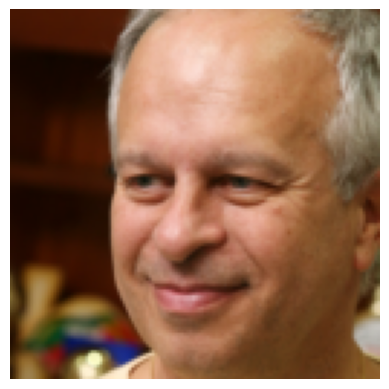

In [4]:
for batch in dataloader:
    tensor = batch[0]
    tensor_img = (tensor + 1) / 2
    tensor_img = tensor_img.clamp(0, 1)
    tensor_img = tensor_img.permute(1, 2, 0)

    plt.imshow(tensor_img)
    plt.axis('off')
    plt.show()
    break

## Часть 2. Построение и обучение модели (2 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [5]:
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.ReLU(inplace=True))

        self.downsampling = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=padding)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = self.downsampling(x)
        return x


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, tail_activation = True):
        super(DecoderBlock, self).__init__() 
        
        self.upsampling = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(inplace=True),
        )

        self.layers = nn.Sequential()

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = in_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.LeakyReLU(inplace=True))

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.LeakyReLU(inplace=True))

        if not tail_activation:
            del self.layers[-2:]

    def forward(self, x):
        x = self.upsampling(x)
        
        for layer in self.layers:
            x = layer(x)
        
        return x
    

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_size, conv_channels, image_size):
        super(Generator, self).__init__()

        MIN_SQUARE = 8
        assert image_size in [16, 32, 64, 128, 256, 512, 1024, 2048], "Only 2^N image sizes in range [16; 2048] are allowed"

        self.decoder = nn.Sequential(
            nn.Linear(in_features=latent_size, out_features=MIN_SQUARE * MIN_SQUARE * conv_channels),
            nn.Unflatten(dim=1, unflattened_size=(conv_channels, MIN_SQUARE, MIN_SQUARE)),
        )

        # Динамически добавляем апсемплы до нужного размера изображения
        decoded_image_size = MIN_SQUARE
        while decoded_image_size < image_size:
            is_last = (decoded_image_size * 2 >= image_size)
            self.decoder.add_module(
                f'upsample_{decoded_image_size}',
                DecoderBlock(
                    in_channels=conv_channels, 
                    out_channels=3 if is_last else conv_channels, 
                    depth=2, 
                    tail_activation=not is_last
                ),
            )
            decoded_image_size *= 2

    def forward(self, x):
        x = self.decoder(x)
        x = torch.tanh(x)
        return x
    

class Discriminator(nn.Module):
    def __init__(self, conv_channels, image_size):
        super(Discriminator, self).__init__()
        
        MIN_SQUARE = 16
        assert image_size in [16, 32, 64, 128, 256, 512, 1024, 2048], "Only 2^N image sizes in range [16; 2048] are allowed"

        self.backbone = nn.Sequential()

        downsampled_size = image_size
        while downsampled_size >= MIN_SQUARE * 2:
            self.backbone.add_module(
                f'downsample_{downsampled_size}',
                EncoderBlock(in_channels=3 if downsampled_size == image_size else conv_channels, out_channels=conv_channels, depth=2),
            )
            downsampled_size //= 2
        
        self.conv_high = EncoderBlock(in_channels=conv_channels, out_channels=8, depth=1)
        self.conv_mid = EncoderBlock(in_channels=conv_channels, out_channels=4, depth=1)
        self.conv_low = EncoderBlock(in_channels=conv_channels, out_channels=2, depth=1)
        # Будем конкатенировать фичи трех последних сверток
        flattened_size = ((MIN_SQUARE // 2) ** 2) * 8 + ((MIN_SQUARE // 4) ** 2) * 4 + ((MIN_SQUARE // 8) ** 2) * 2

        self.head = nn.Sequential(
            nn.Linear(in_features=flattened_size, out_features=1),
        )

    def forward(self, x):
        x = self.backbone(x)
        
        high_feat = self.conv_high(x)
        mid_feat = self.conv_mid(nn.functional.avg_pool2d(x, kernel_size=2))
        low_feat = self.conv_low(nn.functional.avg_pool2d(x, kernel_size=4))
        
        combined_feats = torch.cat([
            high_feat.view(high_feat.size(0), -1),
            mid_feat.view(mid_feat.size(0), -1),
            low_feat.view(low_feat.size(0), -1),
        ], dim=1)

        pred = self.head(combined_feats)
        return pred

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [7]:
class ImageLoggerCallback(L.Callback):
    def __init__(self, fixed_z, log_every_n_epochs=1):
        self.log_every_n_epochs = log_every_n_epochs
        self.fixed_z = fixed_z

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch
        if epoch % self.log_every_n_epochs != 0:
            return

        with torch.no_grad():
            z = self.fixed_z.to(pl_module.device)
            generated = pl_module.generator(z).cpu()

        grid = make_grid(generated, nrow=len(generated))

        pl_module.logger.experiment.add_image("Generated", grid, global_step=epoch)

In [11]:
class LitGanModel(L.LightningModule):

    def __init__(self, conv_channels, latent_dim, discriminator_steps=3):
        super().__init__()
        self.save_hyperparameters()
        
        self.automatic_optimization = False

        # дискриминатор будет делать N шагов за 1 шаг генератора
        self.discriminator_steps = discriminator_steps
        
        self.generator = Generator(latent_size=latent_dim, conv_channels=conv_channels, image_size=image_size)
        self.discriminator = Discriminator(conv_channels=conv_channels, image_size=image_size)
        self.loss_generator = nn.BCEWithLogitsLoss()
        self.loss_discriminator = nn.BCEWithLogitsLoss()

        self.latent_dim = latent_dim

    def forward(self, x):
        return self.generator(x)

    def configure_optimizers(self):
        opt_dis = torch.optim.RMSprop(lr=1e-4, alpha=0.99, momentum=0, params=self.discriminator.parameters())
        opt_gen = torch.optim.RMSprop(lr=1e-4, alpha=0.99, momentum=0, params=self.generator.parameters())
        return [opt_dis, opt_gen], []
    

    def train_generator(self, real, optimizer):
        z = torch.randn(real.size(0), self.latent_dim, device=self.device)
        generated = self.generator(z)

        preds_fake = self.discriminator(generated)
        loss = self.loss_generator(preds_fake, torch.ones_like(preds_fake))
        self.log("generator_train_loss", loss, on_epoch=True, prog_bar=True)
        
        optimizer.zero_grad()
        self.manual_backward(loss)
        optimizer.step()


    def train_discriminator(self, real, optimizer):
        preds_real = self.discriminator(real)
        loss_real = self.loss_discriminator(preds_real, torch.ones_like(preds_real))
        
        z = torch.randn(real.size(0), self.latent_dim, device=self.device)
        generated = self.generator(z).detach()

        preds_fake = self.discriminator(generated)
        loss_fake = self.loss_discriminator(preds_fake, torch.zeros_like(preds_fake))
        
        loss = loss_real + loss_fake
        
        self.log("discriminator_train_loss_real", loss_real, on_epoch=True)
        self.log("discriminator_train_loss_fake", loss_fake, on_epoch=True)
        self.log("discriminator_train_loss_sum", loss, on_epoch=True, prog_bar=True)

        self.log("discriminator_mean_pred_real", preds_real.mean())
        self.log("discriminator_mean_pred_fake", preds_fake.mean())
        
        optimizer.zero_grad()
        self.manual_backward(loss)
        optimizer.step()


    def training_step(self, batch, batch_idx):
        opt_discr, opt_gen = self.optimizers() 

        for _ in range(self.discriminator_steps):
            self.train_discriminator(batch, optimizer=opt_discr)
        
        self.train_generator(batch, optimizer=opt_gen)



In [12]:
latent_size = 100
conv_channels=32

lit_model = LitGanModel(latent_dim=latent_size, conv_channels=conv_channels).to(DEVICE)

summary(lit_model.discriminator, input_size=(1,3,image_size,image_size))
summary(lit_model.generator, input_size=(1,latent_size))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 3, 128, 128]          --
├─Sequential: 1-1                        [1, 3, 128, 128]          --
│    └─Linear: 2-1                       [1, 2048]                 206,848
│    └─Unflatten: 2-2                    [1, 32, 8, 8]             --
│    └─DecoderBlock: 2-3                 [1, 32, 16, 16]           --
│    │    └─Sequential: 3-1              [1, 32, 16, 16]           9,248
│    │    └─Sequential: 3-2              --                        18,624
│    └─DecoderBlock: 2-4                 [1, 32, 32, 32]           --
│    │    └─Sequential: 3-3              [1, 32, 32, 32]           9,248
│    │    └─Sequential: 3-4              --                        18,624
│    └─DecoderBlock: 2-5                 [1, 32, 64, 64]           --
│    │    └─Sequential: 3-5              [1, 32, 64, 64]           9,248
│    │    └─Sequential: 3-6              --                    

In [ ]:
torch.set_float32_matmul_precision('high')

EXP_NAME = "GAN"
EXP_VERSION = 7
EXP_COMMENT = f"img_{image_size}_conv_{conv_channels}_rmsprop"

checkpoint_cb = ModelCheckpoint(
    dirpath=f"checkpoints/{EXP_NAME}/v{EXP_VERSION}_{EXP_COMMENT}",
    filename=f"{EXP_NAME}-{{epoch:03d}}",
    save_top_k=3,
    save_last=True,
    monitor="generator_train_loss",
    mode="min",
)

logger_cb = ImageLoggerCallback(log_every_n_epochs=1, fixed_z = torch.randn(size=(8, latent_size)))

trainer = L.Trainer(
    max_epochs=900,
    logger = TensorBoardLogger("lightning_logs", name=EXP_NAME, version=EXP_VERSION),
    log_every_n_steps=5,
    callbacks=[checkpoint_cb, logger_cb],
)

trainer.fit(lit_model, dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name               | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0 | generator          | Generator         | 309 K  | train | 0    
1 | discriminator      | Discriminator     | 80.3 K | train | 0    
2 | loss_generator     | BCEWithLogitsLoss | 0      | train | 0    
3 | loss_discriminator | BCEWithLogitsLoss | 0      | train | 0    
-------------------------------------------------------------------------
390 K     Trainable params
0         Non-trainable params
390 K     Total params
1.561     Total estimated model params size (MB)
92        Modules in train mode
0         Modules in eval mode
0         Total Flops
c:\Users\efimplotnikov\Projects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' doe

Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

c:\Users\efimplotnikov\Projects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [14]:
trainer.save_checkpoint(f"checkpoints/{EXP_NAME}/v{EXP_VERSION}_{EXP_COMMENT}/{EXP_NAME}-latest-epoch=364.ckpt")

`weights_only` was not set, defaulting to `False`.


Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [15]:
def show_images(generated):
  fig, axes = plt.subplots(1, len(generated))

  for i, tensor in enumerate(generated):
    ax = axes[i]
    tensor = tensor.detach().cpu()
    tensor_img = (tensor + 1) / 2
    tensor_img = tensor_img.clamp(0, 1)
    tensor_img = tensor_img.permute(1, 2, 0)

    ax.imshow(tensor_img)
    ax.axis("off")

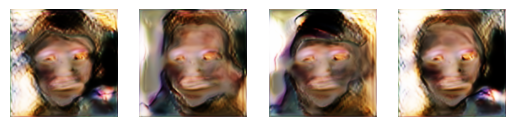

In [32]:
best_gan = LitGanModel.load_from_checkpoint(
    'checkpoints/GAN/v7_img_128_conv_32_rmsprop/GAN-latest-epoch=364.ckpt',
    map_location=DEVICE,
)

n_images = 4

fixed_latent = torch.randn(n_images, latent_size, device=DEVICE)
fake_images = best_gan.generator(fixed_latent)

show_images(fake_images)

Как вам качество получившихся изображений?

In [ ]:
class LitWGanModel(L.LightningModule):

    def __init__(self, conv_channels, latent_dim, critic_steps=3, lambda_gp=10):
        super().__init__()
        self.save_hyperparameters()
        
        self.automatic_optimization = False

        # дискриминатор будет делать N шагов за 1 шаг генератора
        self.critic_steps = critic_steps
        self.lambda_gp = lambda_gp
        
        self.generator = Generator(latent_size=latent_dim, conv_channels=conv_channels, image_size=image_size)
        self.critic = Discriminator(conv_channels=conv_channels, image_size=image_size)

        self.latent_dim = latent_dim

    def forward(self, x):
        return self.generator(x)

    def configure_optimizers(self):
        opt_dis = torch.optim.RMSprop(lr=1e-4, alpha=0.99, momentum=0, params=self.critic.parameters())
        opt_gen = torch.optim.RMSprop(lr=1e-4, alpha=0.99, momentum=0, params=self.generator.parameters())
        return [opt_dis, opt_gen], []
    

    def train_generator(self, real, optimizer):
        z = torch.randn(real.size(0), self.latent_dim, device=self.device)
        generated = self.generator(z)

        scores_fake = self.critic(generated)
        loss = -scores_fake.mean()

        self.log("generator_train_loss", loss, on_epoch=True, prog_bar=True)
        
        optimizer.zero_grad()
        self.manual_backward(loss)
        optimizer.step()


    # TODO: сделать замороченный loss модулем
    def train_critic(self, real, optimizer):
        scores_real = self.critic(real)
        
        z = torch.randn(real.size(0), self.latent_dim, device=self.device)
        generated = self.generator(z).detach()
        scores_fake = self.critic(generated)
        
        # для интерполяции, случайная точка между real и fake
        epsilon = torch.rand(real.size(0), 1, 1, 1, device=self.device)
        # какая-то средняя картинка
        x_hat = epsilon * real + (1 - epsilon) * generated
        x_hat.requires_grad_(True)
        
        # критикуем среднюю картинку
        crit_out = self.critic(x_hat)

        # берем градиент критика по средней картинке
        grad = torch.autograd.grad(outputs=crit_out, inputs=x_hat, grad_outputs=torch.ones_like(crit_out), create_graph=True)[0]
        grad_norm = grad.view(real.size(0), -1).norm(2, dim=1)
        # и штрафуем его, если он начинает нарушать ограничение по Липшицу
        gp = self.lambda_gp * ((grad_norm - 1) ** 2).mean()

        loss = scores_fake.mean() - scores_real.mean() + gp
        
        self.log("critic_loss", loss, on_epoch=True)
        self.log("critic_gradient_penalty", gp, on_epoch=True)
        
        optimizer.zero_grad()
        self.manual_backward(loss)
        optimizer.step()


    def training_step(self, batch, batch_idx):
        opt_discr, opt_gen = self.optimizers() 

        for _ in range(self.critic_steps):
            self.train_critic(batch, optimizer=opt_discr)
        
        self.train_generator(batch, optimizer=opt_gen)

In [ ]:
torch.set_float32_matmul_precision('high')

lit_model = LitWGanModel(latent_dim=latent_size, conv_channels=conv_channels).to(DEVICE)

EXP_NAME = "WGAN"
EXP_VERSION = 1
EXP_COMMENT = f"img_{image_size}_conv_{conv_channels}_rmsprop"

checkpoint_cb = ModelCheckpoint(
    dirpath=f"checkpoints/{EXP_NAME}/v{EXP_VERSION}_{EXP_COMMENT}",
    filename=f"{EXP_NAME}-{{epoch:03d}}",
    save_top_k=3,
    monitor="generator_train_loss",
    mode="min",
)

logger_cb = ImageLoggerCallback(log_every_n_epochs=1, fixed_z = torch.randn(size=(8, latent_size)))

trainer = L.Trainer(
    max_epochs=900,
    logger = TensorBoardLogger("lightning_logs", name=EXP_NAME, version=EXP_VERSION),
    log_every_n_steps=5,
    callbacks=[checkpoint_cb, logger_cb],
)

trainer.fit(lit_model, dataloader)

## Часть 4. Leave-one-out-1-NN classifier accuracy (6 баллов)

### 4.1. Подсчет accuracy (1.5 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

### 4.2. Визуализация распределений (1 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

Прокомментируйте получившийся результат: